<a href="https://colab.research.google.com/github/makoto263/coffee-copywriter/blob/main/create_copy2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##데이터셋 준비

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

#drive에 저장되어 있는 데이터 셋 불어오기
df = pd.read_csv('/content/drive/MyDrive/자연어정보분석/final_copy_dataset_3000_gemini_pro.csv')

###데이터셋을 train test val으로 나누기

In [3]:
!pip install "datasets<4.4.0" pyarrow

In [4]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

#train data 80% 나모지 데이터 20% 비율으로 나누기
#stratify=df['emotion']으로 하고 데이터셋 안에 감정 라벨의 비율을 유지
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label'] #감정을 라벨의 비율을 유지하기 위한 코드
)


#나문 데이터 20%을 반으로 나눠 val 10% test 10%에 한다
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

print(f"学習用(Train): {len(train_df)}件")
print(f"検証用(Validation): {len(val_df)}件")
print(f"テスト用(Test): {len(test_df)}件")

# Hugging Face의 Dataset현식으로 바꾸고 하나로 묶음
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True))
})

学習用(Train): 2400件
検証用(Validation): 300件
テスト用(Test): 300件


##다시 학습시키기3

###환경설정

transformer의 version을 적합한 모델으로 설정히고 다운

In [5]:
!pip install "transformers==4.46.3" --force-reinstall --no-deps

  Using cached transformers-4.46.3-py3-none-any.whl.metadata (44 kB)
Using cached transformers-4.46.3-py3-none-any.whl (10.0 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.6
    Uninstalling transformers-4.57.6:
      Successfully uninstalled transformers-4.57.6


In [6]:
#version 확인
!pip show transformers

Name: transformers
Version: 4.46.3
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: peft, sentence-transformers, trl, unsloth, unsloth_zoo


###model 다운 하기

In [7]:
%%capture
!pip install --upgrade pip
!pip install "unsloth==2026.6.7" "unsloth_zoo"
!pip install --no-deps "trl==0.15.2" peft accelerate bitsandbytes "datasets<4.4.0" pyarrow
!pip install "transformers>=4.50.3,<5.0.0"

In [8]:
# model의 version 확인
import unsloth, transformers, trl
print(unsloth.__version__, transformers.__version__, trl.__version__)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
2026.6.7 4.57.6 0.15.2


basemodel이 작동하는지 확인

*처음에 환경과 model version이 잘 안 맞아서 basemodel이 작동 안 했다 -> basemodel이 작동 안 했는데 학습을 시켜도 성능이 향상하지 안음 = basemodel이 작동하는지 확인 빌수

In [9]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gemma-2-2b-it-bnb-4bit",
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(base_model)

base_tokenizer = get_chat_template(base_tokenizer, chat_template="gemma2")

messages = [
    {"role": "user", "content": "Create an engaging tagline for a canned coffee that perfectly matches the mood of the following social media post.\nPost: i still feel that to some extent but mostly i feel scared and anxious now"}
]
prompt = base_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = base_tokenizer([prompt], return_tensors="pt", add_special_tokens=False).to("cuda")

outputs = base_model.generate(
    input_ids = inputs["input_ids"],
    attention_mask = inputs["attention_mask"],
    max_new_tokens = 45,
    do_sample = False,
    repetition_penalty = 1.3,
)
print(base_tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True))

==((====))==  Unsloth 2026.6.7: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

Unsloth: Will map <end_of_turn> to EOS = <eos>.


Here are some taglines, playing on different aspects of anxiety/fear while keeping it in line with "canned coffee" imagery:

**Direct & Relatable:**

* **Coffee's not magic, but it


###모델 학습 시키기

모델 학습 준비

1. 모델 설정
2. 입력 데이터를 모델이 학습 할 수 있는 형태로 바꾸기

In [10]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gemma-2-2b-it-bnb-4bit",
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(tokenizer, chat_template="gemma2")

def format_chat(examples):
    texts = []
    for sns_post, copy in zip(examples["text"], examples["generated_copy"]):
        messages = [
            {"role": "user", "content": f"Create an engaging tagline for a canned coffee that perfectly matches the mood of the following social media post.\nPost: {sns_post}"},
            {"role": "assistant", "content": copy}
        ]
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False,
            add_special_tokens=False
        )
        texts.append(text)
    return {"text": texts}

formatted_train = dataset["train"].map(format_chat, batched=True)
formatted_val = dataset["validation"].map(format_chat, batched=True)

==((====))==  Unsloth 2026.6.7: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2026.6.7 patched 26 layers with 26 QKV layers, 26 O layers and 26 MLP layers.


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

입력 데이터가 모델이 학습 가능한 형태로 되어 있는지 확인

In [11]:
print(repr(formatted_train[0]["text"]))

'<bos><start_of_turn>user\nCreate an engaging tagline for a canned coffee that perfectly matches the mood of the following social media post.\nPost: i don t think i ll be going back to rift just yet the characters in lotro are far better animated the crafting is a lot better implemented and there s a story that i feel bothered about<end_of_turn>\n<start_of_turn>model\nWhen bad design makes you mad, refresh your standards with a perfectly crafted canned coffee.<end_of_turn>\n'


모델 학습 시키기

In [12]:
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = formatted_train,
    eval_dataset = formatted_val,
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2,
    packing = False,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        per_device_eval_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        num_train_epochs = 3,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 10,
        eval_strategy = "steps",
        eval_steps = 100,
        save_strategy = "steps",
        save_steps = 100,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part = "<start_of_turn>model\n"
)

trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/2400 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/300 [00:00<?, ? examples/s]

Map (num_proc=6):   0%|          | 0/2400 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/2400 [00:00<?, ? examples/s]

Map (num_proc=6):   0%|          | 0/300 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/300 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,400 | Num Epochs = 3 | Total steps = 900
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 20,766,720 of 2,635,108,608 (0.79% trained)


Step,Training Loss,Validation Loss
100,1.671800,1.645279
200,1.473800,1.561583
300,1.516100,1.533799
400,1.172900,1.573234
500,1.096700,1.581280
600,1.064800,1.555777
700,0.655100,1.871478
800,0.680500,1.931153
900,0.678100,1.952142


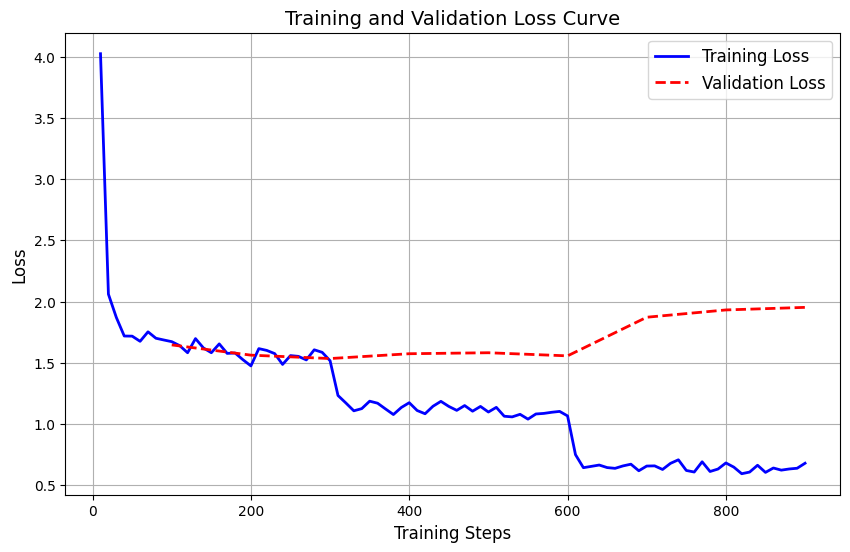

In [17]:
import matplotlib.pyplot as plt

# 学習の履歴（ログ）をAIの記憶から取り出す
history = trainer.state.log_history

# グラフ用の空のリストを準備
train_steps = []
train_loss = []
eval_steps = []
eval_loss = []

# ログの中から「学習Loss」と「検証Loss」を仕分ける
for log in history:
    if "loss" in log and "step" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])
    elif "eval_loss" in log and "step" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])

# グラフの描画設定
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", color="blue", linewidth=2)
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Validation Loss", color="red", linewidth=2, linestyle="--")

plt.title("Training and Validation Loss Curve", fontsize=14)
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# グラフを表示（右クリックで画像として保存できます！）
plt.show()

모델을 Drive에 저장하고 runtime 끊겨도 학습된 모델을 불어 쓸 수 있게 하기

In [13]:
save_path = "/content/drive/MyDrive/자연어정보분석/gemma2_coffee_lora_3"

# LoRA의 가준지과 tokenizer를 저장
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"{save_path}의 모델 저장 완료")

/content/drive/MyDrive/자연어정보분석/gemma2_coffee_lora_3의 모델 저장 완료


Drive에 조장 한 모델을 불어오는 코드

In [14]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
save_path = "/content/drive/MyDrive/자연어정보분석/gemma2_coffee_lora_3"

#Drive에 저장한 LoRA의 가준지를 직접 불로오기
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = save_path,
    max_seq_length = max_seq_length,
    dtype = None,
    load_in_4bit = True,
)

# 추론 모드
FastLanguageModel.for_inference(model)

RuntimeError: Unsloth: No config file found - are you sure the `model_name` is correct?
If you're using a model on your local device, confirm if the folder location exists.
If you're using a HuggingFace online model, check if it exists.

test데이터를 사용하고 LoRA가 있는 모델과 없는 모델의 비교

In [16]:
import warnings
from transformers import logging as hf_logging
from unsloth import FastLanguageModel

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

FastLanguageModel.for_inference(model)

def generate_copy(sns_post, use_lora=True):
    messages = [
        {"role": "user", "content": f"Create an engaging tagline for a canned coffee that perfectly matches the mood of the following social media post.\nPost: {sns_post}"}
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )
    inputs = tokenizer(
        [prompt], return_tensors="pt", add_special_tokens=False
    ).to("cuda")

    if use_lora:
        outputs = model.generate(
            input_ids = inputs["input_ids"],
            attention_mask = inputs["attention_mask"],
            max_new_tokens = 45,
            do_sample = False,
            repetition_penalty = 1.3,
            eos_token_id = tokenizer.eos_token_id,
            pad_token_id = tokenizer.eos_token_id,
        )
    else:
        # LoRAを一時的に無効化してベースモデルの出力を取得
        with model.disable_adapter():
            outputs = model.generate(
                input_ids = inputs["input_ids"],
                attention_mask = inputs["attention_mask"],
                max_new_tokens = 45,
                do_sample = False,
                repetition_penalty = 1.3,
                eos_token_id = tokenizer.eos_token_id,
                pad_token_id = tokenizer.eos_token_id,
            )

    input_length = inputs["input_ids"].shape[1]
    return tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True).strip()


print("====  LoRA유무 비교 ====")
for i in range(5):
    sample = dataset["validation"][i]
    sns_post = sample["text"]
    true_copy = sample["generated_copy"]

    no_lora_answer = generate_copy(sns_post, use_lora=False)
    lora_answer = generate_copy(sns_post, use_lora=True)

    print(f"\n[검증 케이스 {i+1}]")
    print(f"사용자가 SNS에 게시한 문장: {sns_post}")
    print(f"정답 copy: {true_copy}")
    print(f"LoRA가 없는 모델의 copy: {no_lora_answer}")
    print(f"LoRA가 있는 모델의 copy: {lora_answer}")
    print("-" * 60)

====  LoRA유무 비교 ====

[검증 케이스 1]
사용자가 SNS에 게시한 문장: i still feel that to some extent but mostly i feel scared and anxious now
정답 copy: When fear sets in, find your clear focus in every can.
LoRA가 없는 모델의 copy: Here are some taglines, playing on different aspects of anxiety/fear while keeping it in line with "canned coffee" imagery:

**Direct & Relatable:**

* **Coffee's not magic, but it
LoRA가 있는 모델의 copy: When fear lingers, find your steady anchor in every can.
------------------------------------------------------------

[검증 케이스 2]
사용자가 SNS에 게시한 문장: i feel completely assaulted by constant need henpecked
정답 copy: Find your personal shield against the endless demands in a refreshing can of coffee.
LoRA가 없는 모델의 copy: Here are some taglines, playing on different aspects of your post's humor and frustration to match its tone:

**Humorous & Relatable:**

* **"Finally! A caffeine escape from being *told what
LoRA가 있는 모델의 copy: Free yourself from the relentless demands; your moment is now with

##GGUF형식으로 다운하기

In [19]:
# Google Drive의「자연어정보분석」파일에 직접적으로 저장
save_drive_path = "/content/drive/MyDrive/자연어정보분석/gemma2_coffee_lora_gguf"

print("Google Drive에 다운 시작 하기")

model.save_pretrained_gguf(
    save_drive_path,
    tokenizer,
    quantization_method = "q4_k_m"
)

print(f"완료")

Google Drive에 다운ㄴ 시작 하기
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [05:19<00:00, 319.72s/it]


Downloaded tokenizer.model


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [03:28<00:00, 208.25s/it]


Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/자연어정보분석/gemma2_coffee_lora_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/drive/MyDrive/자연어정보분석/gemma2_coffee_lora_gguf_gguf/gemma-2-2b-it.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/drive/MyDrive/자연어정보분